In [1]:
%matplotlib inline

import mne
from mne.datasets import eegbci
from mne.decoding import CSP
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import cross_val_score, StratifiedKFold

mne.set_log_level('WARNING')

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..')) if 'notebooks' in os.getcwd() else os.getcwd()
RESULTS_DIR = os.path.join(REPO_ROOT, 'results')
os.makedirs(RESULTS_DIR, exist_ok=True)

runs = [6, 10]
n_subjects = 20  

In [2]:
def process_subject(subject):
    """Load, preprocess and classify one subject. Returns mean accuracy."""
    try:
        raw_files = eegbci.load_data(subject, runs)
        raw = mne.concatenate_raws([mne.io.read_raw_edf(f, preload=True) 
                                    for f in raw_files])
        mne.datasets.eegbci.standardize(raw)
        raw.set_montage(mne.channels.make_standard_montage('standard_1005'))
        raw_filtered = raw.copy().filter(l_freq=8., h_freq=30.)

        events, _ = mne.events_from_annotations(raw_filtered)
        epochs = mne.Epochs(raw_filtered, events, event_id={'T1': 2, 'T2': 3},
                            tmin=0.0, tmax=4.0, baseline=None, preload=True)

        X = epochs.get_data()
        y = epochs.events[:, 2]

        if len(np.unique(y)) < 2 or len(y) < 10:
            return None  # skip subjects with too few epochs

        csp = CSP(n_components=4, reg=None, log=True, norm_trace=False)
        clf = Pipeline([('csp', csp), ('lda', LinearDiscriminantAnalysis())])

        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        scores = cross_val_score(clf, X, y, cv=cv, scoring='accuracy')
        return scores.mean()

    except Exception as e:
        print(f"Subject {subject} failed: {e}")
        return None

# Run over all subjects
accuracies = {}
for subj in range(1, n_subjects + 1):
    acc = process_subject(subj)
    if acc is not None:
        accuracies[subj] = acc
        print(f"Subject {subj:03d}: {acc*100:.1f}%")
    else:
        print(f"Subject {subj:03d}: skipped")

print(f"\nDone. {len(accuracies)} subjects processed.")
print(f"Mean accuracy: {np.mean(list(accuracies.values()))*100:.1f}%")
print(f"Best subject: {max(accuracies, key=accuracies.get)} ({max(accuracies.values())*100:.1f}%)")
print(f"Worst subject: {min(accuracies, key=accuracies.get)} ({min(accuracies.values())*100:.1f}%)")

Subject 001: 93.3%
Subject 002: 63.3%
Subject 003: 30.0%
Subject 004: 80.0%
Subject 005: 50.0%


Subject 006: 53.3%


Subject 007: 100.0%


Subject 008: 96.7%


Subject 009: 46.7%


...

Subject 016: 66.7%


Subject 017: 53.3%


Subject 018: 50.0%


Subject 019: 70.0%


Subject 020: 46.7%

Done. 20 subjects processed.
Mean accuracy: 67.2%
Best subject: 7 (100.0%)
Worst subject: 3 (30.0%)


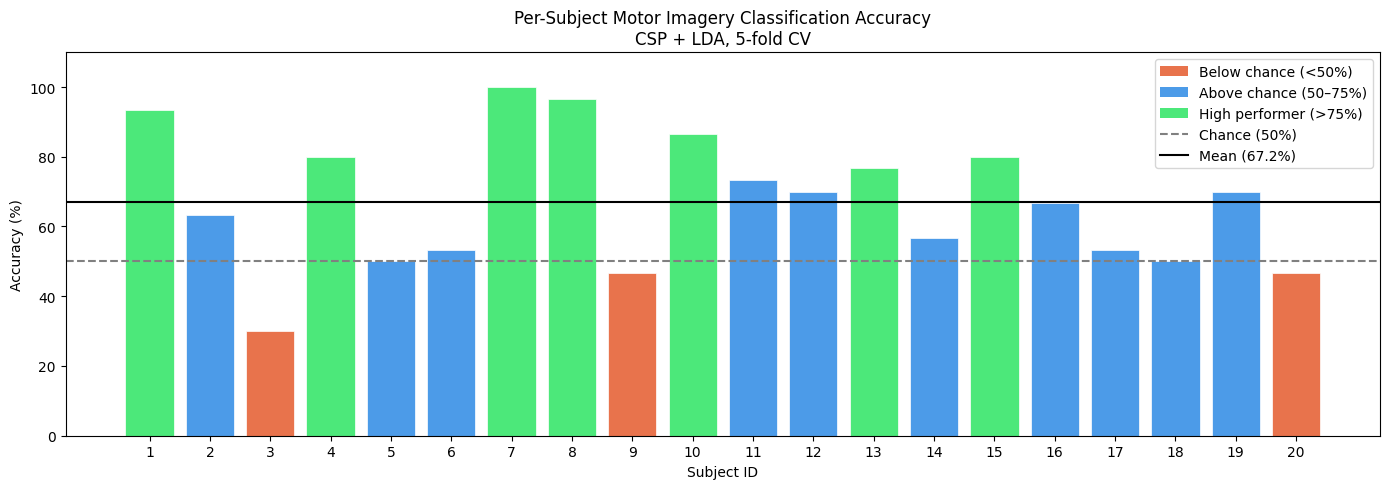

In [3]:
subjects = list(accuracies.keys())
accs = [accuracies[s] * 100 for s in subjects]

# color bars by performance
colors = ['#E8734C' if a < 50 else '#4C9BE8' if a < 75 else '#4CE87A' for a in accs]

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(subjects, accs, color=colors, edgecolor='white', linewidth=0.5)

ax.axhline(y=50, color='gray', linestyle='--', linewidth=1.5, label='Chance (50%)')
ax.axhline(y=np.mean(accs), color='black', linestyle='-', linewidth=1.5,
           label=f'Mean ({np.mean(accs):.1f}%)')

ax.set_xlabel('Subject ID')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Per-Subject Motor Imagery Classification Accuracy\nCSP + LDA, 5-fold CV')
ax.set_xticks(subjects)
ax.set_ylim(0, 110)
ax.legend()

# color legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#E8734C', label='Below chance (<50%)'),
    Patch(facecolor='#4C9BE8', label='Above chance (50–75%)'),
    Patch(facecolor='#4CE87A', label='High performer (>75%)')
]
ax.legend(handles=legend_elements + [
    plt.Line2D([0], [0], color='gray', linestyle='--', label='Chance (50%)'),
    plt.Line2D([0], [0], color='black', label=f'Mean ({np.mean(accs):.1f}%)')
])

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '07_per_subject_accuracy.png'),
            dpi=150, bbox_inches='tight')
plt.show()
plt.close()